# Compare training experiments

This notebook is a read-only view over runs saved in `artifacts/experiments`. It compares headline prediction and betting metrics, shows exactly which configurations differ, and inspects threshold, Optuna, feature-schema, and residual behavior.

> A ranking is only an apples-to-apples comparison when the runs use the same holdout dates and games. The cohort check below makes differences visible before plotting results.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Could not find the project root containing pyproject.toml.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_pipeline import build_leaderboard

EXPERIMENT_ROOT = PROJECT_ROOT / "artifacts" / "experiments"

# ===========================================================================
# WHICH RUNS TO COMPARE
#
# Option A -- name runs explicitly. Accepts an experiment_id, a full run_name,
# or a run_name prefix. When this list is non-empty it OVERRIDES the tag
# filters below, which is the quickest way to compare two specific runs no
# matter how they were tagged.
EXPERIMENT_IDS: list[str] = []
# e.g.
# EXPERIMENT_IDS = ["13d5a8374986", "17fa570a0e86"]                    # by id
# EXPERIMENT_IDS = ["total_points_2500_old_games_20260704_20260802"]   # by prefix

# Option B -- filter by tag. Used only when EXPERIMENT_IDS is empty.
# Set either to None to skip that filter.
TARGET_FAMILY = "total_points"
COMPARISON_GROUP = "total_points_dataset_ab_2026_08"

# Collapse repeated executions of the same setup down to the newest one.
# Ignored under Option A: naming runs explicitly means you want all of them.
KEEP_LATEST_PER_KEY = True
# ===========================================================================

# -110 American odds, the standard price on NBA totals. Break-even win rate
# is 1/odds = 52.38%. Defined once here because several sections need it.
DECIMAL_ODDS = 1.0 + 100.0 / 110.0
BREAK_EVEN_PCT = 100.0 / DECIMAL_ODDS

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
plt.style.use("seaborn-v0_8-whitegrid")


# --- shared helpers (defined here so every later section can use them) ------

def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text())


def flatten_mapping(value: dict, prefix: str = "") -> dict[str, object]:
    flattened = {}
    for key, item in value.items():
        full_key = f"{prefix}.{key}" if prefix else key
        if isinstance(item, dict):
            flattened.update(flatten_mapping(item, full_key))
        else:
            flattened[full_key] = item
    return flattened


def display_value(value: object) -> object:
    if isinstance(value, (dict, list, tuple)):
        return json.dumps(value, sort_keys=True)
    return value


print("Project root:", PROJECT_ROOT)
print("Experiment root:", EXPERIMENT_ROOT)

Project root: /home/adrian_alvarez/Projects/NBA_over_under_predictor
Experiment root: /home/adrian_alvarez/Projects/NBA_over_under_predictor/artifacts/experiments


## 1. Discover and select runs

Two ways to choose what gets compared, set in the cell above:

- **`EXPERIMENT_IDS`** — name runs explicitly by `experiment_id`, full `run_name`, or a `run_name` prefix. Overrides the filters when non-empty.
- **`TARGET_FAMILY` / `COMPARISON_GROUP`** — filter by tag. Set either to `None` to skip it.

If nothing matches, the error lists every run that exists so you can see what to ask for. `KEEP_LATEST_PER_KEY` collapses repeat executions of the same setup to the newest one; it is ignored when selecting explicitly.

In [2]:
# Load every run first, so an unmatched filter can show you what DOES exist
# rather than just failing.
leaderboard = build_leaderboard(EXPERIMENT_ROOT)
if leaderboard.empty:
    raise ValueError(
        f"No runs found under {EXPERIMENT_ROOT}. Run an experiment first:\n"
        "  poetry run python -m training_pipeline.cli experiments/<...>.yaml"
    )

leaderboard["created_at"] = pd.to_datetime(leaderboard["created_at"], errors="coerce")


def _available() -> str:
    catalogue = leaderboard[
        ["run_name", "experiment_id", "target_family", "comparison_group", "created_at"]
    ].sort_values("created_at", ascending=False)
    return catalogue.to_string(index=False)


if EXPERIMENT_IDS:
    # --- Option A: explicit selection -------------------------------------
    wanted = [str(x).strip() for x in EXPERIMENT_IDS if str(x).strip()]

    def _matches(row, token: str) -> bool:
        return (
            token == str(row["experiment_id"])
            or token == str(row["run_name"])
            or str(row["run_name"]).startswith(token)
        )

    unmatched = [t for t in wanted if not leaderboard.apply(_matches, axis=1, args=(t,)).any()]
    if unmatched:
        raise ValueError(
            f"No run matches {unmatched}. Give an experiment_id, a full run_name, "
            f"or a run_name prefix.\n\nAvailable runs:\n{_available()}"
        )

    mask = leaderboard.apply(lambda r: any(_matches(r, t) for t in wanted), axis=1)
    comparison = leaderboard.loc[mask].copy()
    selection_mode = f"manual selection of {len(wanted)} identifier(s)"
    collapse = False  # you named them; show them all
else:
    # --- Option B: filter by tag ------------------------------------------
    comparison = leaderboard.copy()
    applied = []
    if TARGET_FAMILY is not None:
        comparison = comparison.loc[comparison["target_family"] == TARGET_FAMILY]
        applied.append(f"target_family={TARGET_FAMILY!r}")
    if COMPARISON_GROUP is not None:
        comparison = comparison.loc[comparison["comparison_group"] == COMPARISON_GROUP]
        applied.append(f"comparison_group={COMPARISON_GROUP!r}")

    if comparison.empty:
        raise ValueError(
            f"No runs match {' and '.join(applied) or '(no filters)'}.\n"
            "Either fix the filters above, or set EXPERIMENT_IDS to pick runs "
            f"by hand.\n\nAvailable runs:\n{_available()}"
        )
    selection_mode = " and ".join(applied) or "no filters"
    collapse = KEEP_LATEST_PER_KEY

comparison = comparison.copy()
comparison["comparison_key"] = (
    comparison["data_version"]
    .fillna(comparison["training_version"])
    .fillna(comparison["config_fingerprint"])
    .fillna(comparison["run_name"])
)

all_group_runs = comparison.sort_values("created_at").reset_index(drop=True)
if collapse:
    selected_runs = (
        all_group_runs.groupby("comparison_key", dropna=False, as_index=False)
        .tail(1)
        .sort_values("comparison_key")
        .reset_index(drop=True)
    )
else:
    selected_runs = all_group_runs.copy()

# Duplicate keys would silently overwrite each other in the config/feature
# sections, which index by comparison_key.
duplicates = selected_runs["comparison_key"].duplicated(keep=False)
if duplicates.any():
    selected_runs.loc[duplicates, "comparison_key"] = (
        selected_runs.loc[duplicates, "comparison_key"].astype(str)
        + " ["
        + selected_runs.loc[duplicates, "experiment_id"].astype(str).str[:6]
        + "]"
    )

run_columns = [
    "run_name", "experiment_id", "comparison_key", "data_version",
    "training_version", "created_at", "holdout_start", "holdout_end",
    "holdout_n_games", "config_fingerprint",
]
display(all_group_runs[[c for c in run_columns if c in all_group_runs.columns]])
display(Markdown(
    f"**Selected {len(selected_runs)} of {len(leaderboard)} run(s)** "
    f"via {selection_mode}."
))

,run_name,experiment_id,comparison_key,data_version,training_version,created_at,holdout_start,holdout_end,holdout_n_games,config_fingerprint
0,total_points_2500_old_games_20260704_20260802_115707,13d5a8374986,20260704-old-3240col,20260704-old-3240col,old,2026-08-02 11:57:07.208227+00:00,2026-03-08T00:00:00,2026-04-17T00:00:00,287,d1b847f75d5b
1,total_points_2500_games_train_2_0_20260802_131637,17fa570a0e86,20260704-train-2-0,20260704-train-2-0,2.0,2026-08-02 13:16:37.233452+00:00,2026-03-07T00:00:00,2026-04-17T00:00:00,293,6d65ecc6fa96


**Selected 2 of 2 run(s)** via target_family='total_points' and comparison_group='total_points_dataset_ab_2026_08'.

## 2. Verify the evaluation cohort

MAE, win rate, and ROI can only be compared directly when they were measured over the same evaluation cohort. This check is deliberately prominent.

In [3]:
cohort_columns = [
    "holdout_start", "holdout_end", "holdout_n_games", "n_candidates"
]
cohorts = selected_runs[[c for c in cohort_columns if c in selected_runs.columns]].drop_duplicates()
display(cohorts)

cohorts_are_comparable = len(cohorts) == 1
if cohorts_are_comparable:
    display(Markdown("✅ **The selected runs report the same holdout boundaries and size.**"))
else:
    display(Markdown(
        "⚠️ **The selected runs use different holdout cohorts.** The charts remain useful "
        "for describing each run, but they do not isolate the effect of the changed dataset or configuration."
    ))

,holdout_start,holdout_end,holdout_n_games,n_candidates
0,2026-03-08T00:00:00,2026-04-17T00:00:00,287,287
1,2026-03-07T00:00:00,2026-04-17T00:00:00,293,293


⚠️ **The selected runs use different holdout cohorts.** The charts remain useful for describing each run, but they do not isolate the effect of the changed dataset or configuration.

## 3. Headline metrics

Two distinct questions, kept separate on purpose:

- **Cross-validation** (`cv_*`) — how the configuration behaved across the walk-forward folds *inside the development period*. This is what Optuna optimised, and it is the more stable signal because it averages many folds.
- **Test set** (`final_test_*`, `roi`) — a single held-out period the model never saw. Fewer games, so noisier, but it is the honest estimate.

Both are compared against the same reference: **trusting the bookmaker's closing line**. `bias_baseline_*` is the harder null — the line plus its historical drift — because a model that only rediscovers a league-wide over/under tendency will beat the raw line but not this one.

Read ROI together with bet volume and its win-rate confidence interval. A high ROI on very few bets is not evidence.

In [4]:
def _pct_frame(df: pd.DataFrame, percent_columns, float_columns=()):
    """Style a table: percentages as %, everything else to 3 decimals."""
    formatters = {c: "{:.2%}" for c in percent_columns if c in df.columns}
    formatters.update({c: "{:.3f}" for c in float_columns if c in df.columns})
    return df.style.format(formatters, na_rep="—")


# --- cross-validation: averaged over folds, so the more stable comparison ---
cv_columns = [
    "comparison_key", "cv_mae", "baseline_cv_mae", "cv_improvement_over_baseline_pct",
    "cv_rmse", "baseline_cv_rmse", "cv_ou_acc", "n_trials", "selected_trial_number",
]
cv_summary = selected_runs.copy()
cv_summary["cv_improvement_over_baseline_pct"] = (
    cv_summary["baseline_cv_mae"] - cv_summary["cv_mae"]
) / cv_summary["baseline_cv_mae"]
cv_summary = cv_summary[[c for c in cv_columns if c in cv_summary.columns]]

display(Markdown("**Cross-validation (development folds)**"))
display(_pct_frame(
    cv_summary,
    percent_columns=["cv_improvement_over_baseline_pct", "cv_ou_acc"],
    float_columns=["cv_mae", "baseline_cv_mae", "cv_rmse", "baseline_cv_rmse"],
))

# --- held-out test period ---
test_columns = [
    "comparison_key", "holdout_start", "holdout_end", "holdout_n_games",
    "final_test_mae", "baseline_holdout_mae", "mae_improvement_over_baseline_pct",
    "bias_baseline_mae", "final_test_ou_acc",
    "bet_min_edge", "roi", "bias_baseline_roi", "roi_vs_bias_baseline",
    "profit_units", "n_bets", "bet_rate",
    "win_rate", "win_rate_ci_low", "win_rate_ci_high",
    "break_even_rate", "is_significant",
]
test_summary = selected_runs[[c for c in test_columns if c in selected_runs.columns]]

display(Markdown("**Held-out test period**"))
display(_pct_frame(
    test_summary,
    percent_columns=[
        "mae_improvement_over_baseline_pct", "final_test_ou_acc", "roi",
        "bias_baseline_roi", "roi_vs_bias_baseline", "bet_rate", "win_rate",
        "win_rate_ci_low", "win_rate_ci_high", "break_even_rate",
    ],
    float_columns=[
        "final_test_mae", "baseline_holdout_mae", "bias_baseline_mae", "profit_units",
    ],
))

# CV and test should broadly agree. When they disagree sharply, the test result
# is usually the small sample talking, not a real regime change.
if {"cv_mae", "final_test_mae"} <= set(selected_runs.columns):
    for row in selected_runs.itertuples(index=False):
        if pd.notna(row.cv_mae) and pd.notna(row.final_test_mae):
            gap = row.final_test_mae - row.cv_mae
            if abs(gap) > 1.0:
                display(Markdown(
                    f"⚠️ **{row.comparison_key}**: test MAE is {gap:+.2f} vs CV MAE "
                    f"({row.final_test_mae:.3f} vs {row.cv_mae:.3f}). A gap this size "
                    "usually reflects a different scoring environment in the holdout "
                    "period rather than a broken model — check the baseline moved too."
                ))

**Cross-validation (development folds)**

,comparison_key,cv_mae,baseline_cv_mae,cv_improvement_over_baseline_pct,cv_rmse,baseline_cv_rmse,cv_ou_acc,n_trials,selected_trial_number
0,20260704-old-3240col,13.046,13.284,1.79%,16.432,16.486,58.51%,100,24
1,20260704-train-2-0,14.848,15.024,1.17%,18.896,18.984,56.87%,100,7


**Held-out test period**

,comparison_key,holdout_start,holdout_end,holdout_n_games,final_test_mae,baseline_holdout_mae,mae_improvement_over_baseline_pct,bias_baseline_mae,final_test_ou_acc,bet_min_edge,roi,bias_baseline_roi,roi_vs_bias_baseline,profit_units,n_bets,bet_rate,win_rate,win_rate_ci_low,win_rate_ci_high,break_even_rate,is_significant
0,20260704-old-3240col,2026-03-08T00:00:00,2026-04-17T00:00:00,287,14.171,14.089,-0.58%,14.089,50.89%,2.000000,-2.79%,-2.79%,0.00%,-3.182,114,39.72%,50.89%,41.76%,59.97%,52.38%,False
1,20260704-train-2-0,2026-03-07T00:00:00,2026-04-17T00:00:00,293,14.687,14.597,-0.62%,14.597,52.68%,2.000000,0.56%,0.56%,0.00%,0.636,114,38.91%,52.68%,43.50%,61.68%,52.38%,False


⚠️ **20260704-old-3240col**: test MAE is +1.12 vs CV MAE (14.171 vs 13.046). A gap this size usually reflects a different scoring environment in the holdout period rather than a broken model — check the baseline moved too.

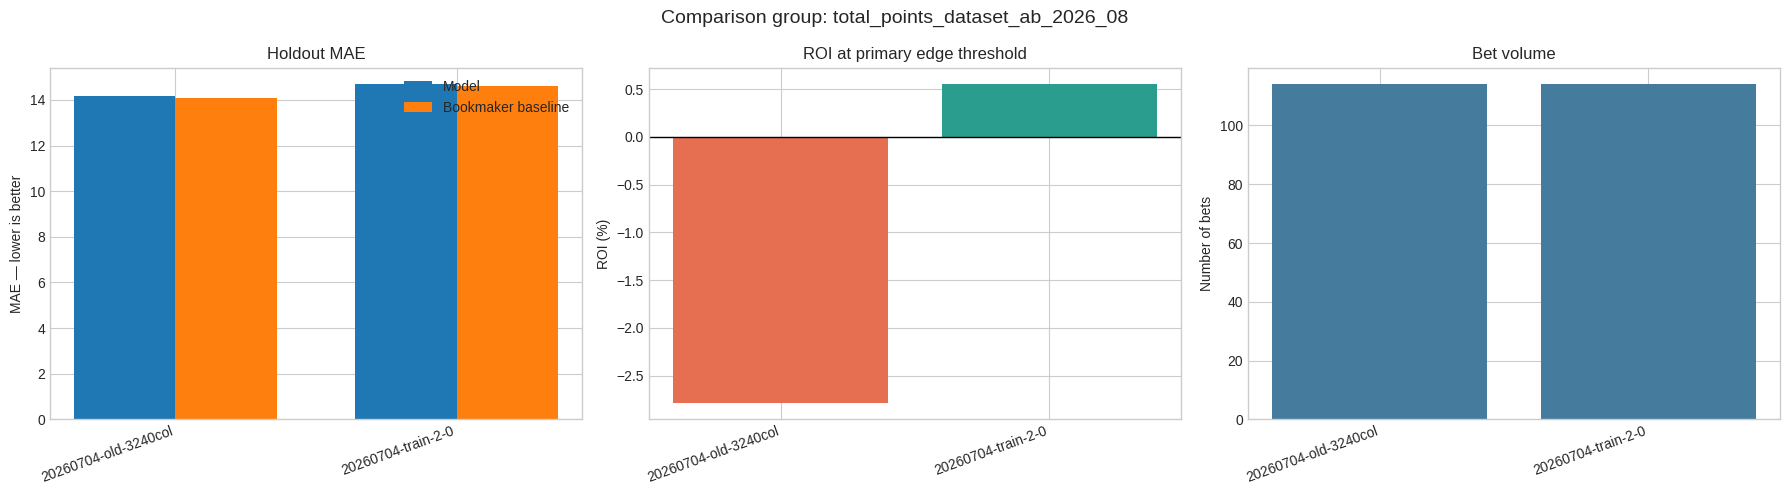

In [5]:
plot_df = selected_runs.set_index("comparison_key")
labels = plot_df.index.astype(str).tolist()
x = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
width = 0.36
axes[0].bar(x - width / 2, plot_df["final_test_mae"], width, label="Model")
axes[0].bar(x + width / 2, plot_df["baseline_holdout_mae"], width, label="Bookmaker baseline")
axes[0].set_title("Holdout MAE")
axes[0].set_ylabel("MAE — lower is better")
axes[0].legend()

roi_pct = plot_df["roi"] * 100
axes[1].bar(x, roi_pct, color=["#2a9d8f" if value >= 0 else "#e76f51" for value in roi_pct.fillna(0)])
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title(f"ROI at primary edge threshold")
axes[1].set_ylabel("ROI (%)")

axes[2].bar(x, plot_df["n_bets"], color="#457b9d")
axes[2].set_title("Bet volume")
axes[2].set_ylabel("Number of bets")

for ax in axes:
    ax.set_xticks(x, labels, rotation=20, ha="right")
fig.suptitle(f"Comparison group: {COMPARISON_GROUP}", fontsize=14)
plt.tight_layout()
plt.show()

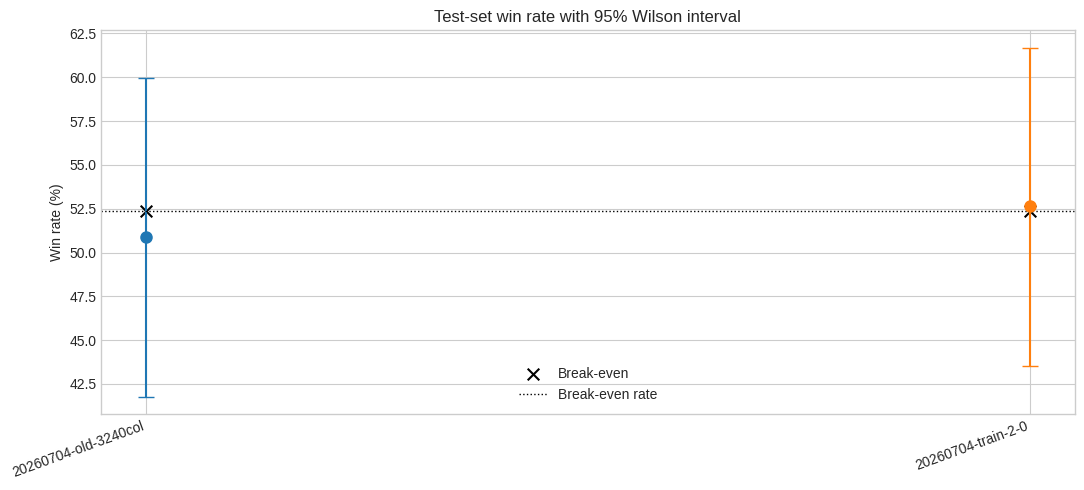

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for position, row in enumerate(selected_runs.itertuples(index=False)):
    if pd.isna(row.win_rate):
        continue
    low = row.win_rate - row.win_rate_ci_low
    high = row.win_rate_ci_high - row.win_rate
    ax.errorbar(
        position, row.win_rate * 100,
        yerr=np.array([[low * 100], [high * 100]]),
        fmt="o", capsize=6, markersize=8,
    )
    ax.scatter(
        position, row.break_even_rate * 100, marker="x", color="black", s=70,
        label="Break-even" if position == 0 else None,
    )
# An interval crossing this line means the edge is not distinguishable from
# noise, however attractive the point estimate looks.
ax.axhline(
    selected_runs["break_even_rate"].dropna().mean() * 100,
    color="black", linestyle=":", linewidth=1, label="Break-even rate",
)
ax.set_xticks(np.arange(len(selected_runs)), selected_runs["comparison_key"], rotation=20, ha="right")
ax.set_ylabel("Win rate (%)")
ax.set_title("Test-set win rate with 95% Wilson interval")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 4. Cross-validation, fold by fold

The headline `cv_mae` is a mean over folds, which hides the thing that matters most: **consistency**. A configuration that beats the line on 8 of 10 folds is a different proposition from one that averages the same number by winning three folds hugely and losing the rest.

Each run stores per-fold model metrics on its selected Optuna trial (`fold_metrics`) and the matching per-fold bookmaker-line baseline in `baseline_fold_metrics.csv`. They join on fold number, which lets us compare the model against the line *within each fold* — the paired comparison, which removes the "some folds are simply harder" confound that makes raw MAE across runs hard to read.

In [7]:
def load_fold_comparison(run_name: str, comparison_key: str) -> pd.DataFrame | None:
    """Per-fold model metrics joined to the per-fold bookmaker-line baseline."""
    run_dir = EXPERIMENT_ROOT / run_name

    trial_path = run_dir / "optuna_selected_trial.json"
    if not trial_path.exists():
        trial_path = run_dir / "optuna_best_trial.json"
    if not trial_path.exists():
        return None  # a run that pinned fixed_params has no trial to read

    payload = read_json(trial_path)
    trial = payload.get("selected_trial") or payload.get("best_trial") or {}
    fold_metrics = (trial.get("user_attrs") or {}).get("fold_metrics")
    if not fold_metrics:
        return None

    model_folds = pd.DataFrame(fold_metrics).rename(
        columns={"mae": "model_mae", "rmse": "model_rmse", "ou_accuracy": "model_ou_acc"}
    )

    baseline_path = run_dir / "baseline_fold_metrics.csv"
    if not baseline_path.exists():
        return None
    baseline_folds = pd.read_csv(baseline_path).rename(
        columns={"mae": "baseline_mae", "rmse": "baseline_rmse"}
    )

    folds = model_folds.merge(
        baseline_folds[["fold", "n_games", "baseline_mae", "baseline_rmse"]],
        on="fold", how="inner",
    )
    folds["comparison_key"] = comparison_key
    # Positive => the model beat the line on that fold.
    folds["mae_edge_vs_line"] = folds["baseline_mae"] - folds["model_mae"]
    folds["beat_line"] = folds["mae_edge_vs_line"] > 0
    return folds


fold_frames = [
    frame
    for row in selected_runs.itertuples(index=False)
    if (frame := load_fold_comparison(row.run_name, str(row.comparison_key))) is not None
]

if not fold_frames:
    display(Markdown(
        "_No per-fold metrics available. Runs that set `optuna.fixed_params` skip "
        "tuning, so they have no Optuna trial to read folds from._"
    ))
    all_folds = pd.DataFrame()
else:
    all_folds = pd.concat(fold_frames, ignore_index=True)

    consistency = (
        all_folds.groupby("comparison_key")
        .agg(
            folds=("fold", "count"),
            folds_beating_line=("beat_line", "sum"),
            mean_mae_edge=("mae_edge_vs_line", "mean"),
            worst_fold_edge=("mae_edge_vs_line", "min"),
            best_fold_edge=("mae_edge_vs_line", "max"),
            mae_edge_std=("mae_edge_vs_line", "std"),
            mean_model_mae=("model_mae", "mean"),
            mean_baseline_mae=("baseline_mae", "mean"),
            mean_ou_acc=("model_ou_acc", "mean"),
        )
        .reset_index()
    )
    consistency["win_rate_across_folds"] = (
        consistency["folds_beating_line"] / consistency["folds"]
    )
    display(_pct_frame(
        consistency,
        percent_columns=["win_rate_across_folds", "mean_ou_acc"],
        float_columns=[
            "mean_mae_edge", "worst_fold_edge", "best_fold_edge", "mae_edge_std",
            "mean_model_mae", "mean_baseline_mae",
        ],
    ))

,comparison_key,folds,folds_beating_line,mean_mae_edge,worst_fold_edge,best_fold_edge,mae_edge_std,mean_model_mae,mean_baseline_mae,mean_ou_acc,win_rate_across_folds
0,20260704-old-3240col,12,10,0.238,-1.931,0.984,0.777,13.046,13.284,58.51%,83.33%
1,20260704-train-2-0,12,9,0.176,-0.387,0.602,0.284,14.848,15.024,56.87%,75.00%


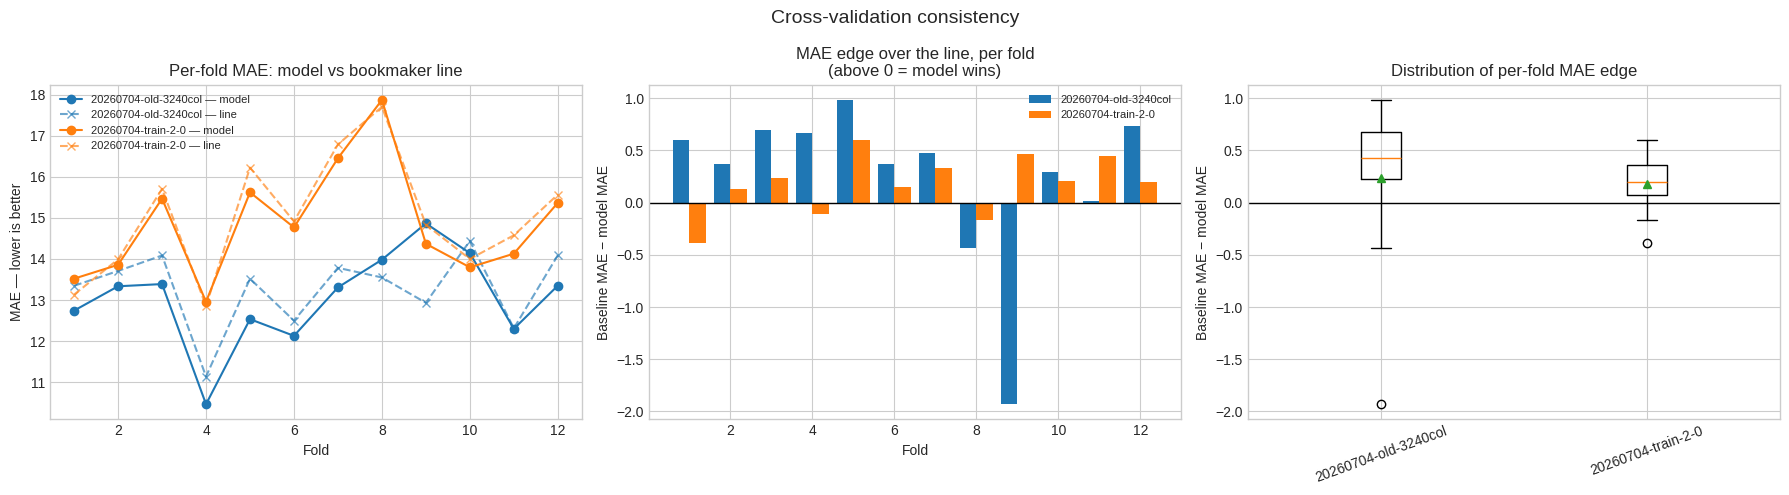

- **20260704-old-3240col**: mean edge +0.238 MAE, fold-to-fold sd 0.777 (mean/sd = 0.31 — noisy — driven by a few folds), beat the line on 10/12 folds.

- **20260704-train-2-0**: mean edge +0.176 MAE, fold-to-fold sd 0.284 (mean/sd = 0.62 — noisy — driven by a few folds), beat the line on 9/12 folds.

In [8]:
if not all_folds.empty:
    keys = all_folds["comparison_key"].unique().tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Model vs line per fold. Folds differ in difficulty, so the gap between
    #    the paired lines matters, not their absolute height.
    for key in keys:
        folds = all_folds[all_folds["comparison_key"] == key].sort_values("fold")
        line, = axes[0].plot(folds["fold"], folds["model_mae"], marker="o", label=f"{key} — model")
        axes[0].plot(
            folds["fold"], folds["baseline_mae"], marker="x", linestyle="--",
            color=line.get_color(), alpha=0.65, label=f"{key} — line",
        )
    axes[0].set_title("Per-fold MAE: model vs bookmaker line")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("MAE — lower is better")
    axes[0].legend(fontsize=8)

    # 2) The paired difference. Above zero = the model beat the line that fold.
    width = 0.8 / max(len(keys), 1)
    for offset, key in enumerate(keys):
        folds = all_folds[all_folds["comparison_key"] == key].sort_values("fold")
        positions = folds["fold"] + (offset - (len(keys) - 1) / 2) * width
        axes[1].bar(positions, folds["mae_edge_vs_line"], width, label=key)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("MAE edge over the line, per fold\n(above 0 = model wins)")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("Baseline MAE − model MAE")
    axes[1].legend(fontsize=8)

    # 3) Spread of that edge. A distribution straddling zero means the average
    #    is carried by a few folds rather than a repeatable advantage.
    axes[2].boxplot(
        [all_folds.loc[all_folds["comparison_key"] == key, "mae_edge_vs_line"] for key in keys],
        tick_labels=keys, showmeans=True,
    )
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title("Distribution of per-fold MAE edge")
    axes[2].set_ylabel("Baseline MAE − model MAE")
    axes[2].tick_params(axis="x", rotation=20)

    fig.suptitle("Cross-validation consistency", fontsize=14)
    plt.tight_layout()
    plt.show()

    # A mean edge that is small relative to its own fold-to-fold spread is not
    # a reliable advantage, whatever the headline cv_mae says.
    for key in keys:
        edges = all_folds.loc[all_folds["comparison_key"] == key, "mae_edge_vs_line"]
        if len(edges) > 1 and edges.std(ddof=1) > 0:
            ratio = edges.mean() / edges.std(ddof=1)
            verdict = "consistent" if ratio > 1 else "noisy — driven by a few folds"
            display(Markdown(
                f"- **{key}**: mean edge {edges.mean():+.3f} MAE, "
                f"fold-to-fold sd {edges.std(ddof=1):.3f} "
                f"(mean/sd = {ratio:.2f} — {verdict}), "
                f"beat the line on {int((edges > 0).sum())}/{len(edges)} folds."
            ))

## 5. Profit across the CV folds — the split with the most bets behind it

The holdout cannot settle the profitability question at its size. At −110 the break-even win rate is 52.38%, and a 95% interval around even a genuinely good 55% win rate does not clear that bar until well over a thousand bets:

| win rate | bets | 95% CI | verdict |
|---|---|---|---|
| 55% | 114 | [46.1%, 64.1%] | cannot prove |
| 55% | 600 | [51.0%, 58.9%] | cannot prove |
| 55% | 1200 | [52.2%, 57.8%] | cannot prove |

A 5% holdout yields ~115 bets. Ranking runs on holdout ROI alone at that volume is close to a coin flip. The CV folds already cover ~5× as many games, so `betting.evaluate_cv_folds` scores them for profit too — one extra fit per fold.

**Read these as a comparison between configurations, not an estimate of live ROI.** These folds selected the hyperparameters, so they are optimistically biased. The bias applies roughly equally to every run, which is what makes the *ranking* usable while the *level* is not. The holdout in §3 remains the out-of-sample estimate — and the gap between the two is itself a result: a large `cv_roi − roi` is the signature of selection overfitting.

In [ ]:
def load_cv_betting(run_name: str, comparison_key: str) -> dict | None:
    """Pooled + per-fold CV betting metrics for one run, if it computed them."""
    run_dir = EXPERIMENT_ROOT / run_name
    summary_path = run_dir / "cv_betting_summary.json"
    folds_path = run_dir / "cv_fold_betting.csv"
    if not summary_path.exists() or not folds_path.exists():
        return None
    return {
        "key": comparison_key,
        "summary": read_json(summary_path),
        "folds": pd.read_csv(folds_path, parse_dates=["valid_start", "valid_end"]),
    }


cv_bets = [
    c for row in selected_runs.itertuples(index=False)
    if (c := load_cv_betting(row.run_name, str(row.comparison_key))) is not None
]

if not cv_bets:
    display(Markdown(
        "_No CV betting artifacts. Set `betting.evaluate_cv_folds: true` "
        "(the default in `_base.yaml`) and rerun — older runs predate this._"
    ))
else:
    # --- pooled CV profit, next to the holdout it is meant to out-power -----
    rows = []
    for entry in cv_bets:
        s = entry["summary"]
        holdout = selected_runs.loc[
            selected_runs["comparison_key"] == entry["key"]
        ].iloc[0]
        rows.append({
            "comparison_key": entry["key"],
            "cv_n_bets": s.get("n_bets"),
            "cv_win_rate": s.get("win_rate"),
            "cv_ci_low": s.get("win_rate_ci_low"),
            "cv_roi": s.get("roi"),
            "cv_significant": s.get("is_significant"),
            "cv_profitable_folds": (
                f"{s.get('n_profitable_folds')}/{s.get('n_folds')}"
            ),
            "holdout_n_bets": holdout.get("n_bets"),
            "holdout_roi": holdout.get("roi"),
            # Positive => the holdout underperformed the folds that chose the
            # hyperparameters, i.e. some of the CV edge was selection.
            "cv_minus_holdout_roi": (
                s.get("roi") - holdout.get("roi")
                if pd.notna(s.get("roi")) and pd.notna(holdout.get("roi")) else None
            ),
            "volume_gain": (
                s.get("n_bets") / holdout.get("n_bets")
                if holdout.get("n_bets") else None
            ),
        })
    cv_betting_table = pd.DataFrame(rows)
    display(Markdown("**Pooled CV profit vs the holdout**"))
    display(_pct_frame(
        cv_betting_table,
        percent_columns=[
            "cv_win_rate", "cv_ci_low", "cv_roi", "holdout_roi",
            "cv_minus_holdout_roi",
        ],
        float_columns=["volume_gain"],
    ))

    for row in cv_betting_table.itertuples(index=False):
        if pd.notna(row.volume_gain):
            display(Markdown(
                f"- **{row.comparison_key}**: {row.cv_n_bets} CV bets vs "
                f"{row.holdout_n_bets} holdout bets "
                f"(**{row.volume_gain:.1f}× the volume**)."
            ))

    # --- per-fold profit: is a pooled ROI carried by one fold? -------------
    keys = [c["key"] for c in cv_bets]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    width = 0.8 / max(len(keys), 1)
    for offset, entry in enumerate(cv_bets):
        folds = entry["folds"].sort_values("fold")
        positions = folds["fold"] + (offset - (len(keys) - 1) / 2) * width
        axes[0].bar(positions, folds["roi"] * 100, width, label=entry["key"])
        axes[1].plot(
            folds["fold"], folds["win_rate"] * 100, marker="o", label=entry["key"]
        )
        axes[2].plot(
            folds["fold"], folds["n_bets"], marker="o", label=entry["key"]
        )

    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("ROI per CV fold\n(above 0 = profitable that fold)")
    axes[0].set_ylabel("ROI (%)")
    # Break-even at -110. A fold above the line still needs volume to mean much.
    axes[1].axhline(BREAK_EVEN_PCT, color="black", linestyle=":",
                    linewidth=1, label="Break-even 52.38%")
    axes[1].set_title("Win rate per CV fold")
    axes[1].set_ylabel("Win rate (%)")
    axes[2].set_title("Bets placed per CV fold")
    axes[2].set_ylabel("Number of bets")
    for ax in axes:
        ax.set_xlabel("Fold")
        ax.legend(fontsize=8)
    fig.suptitle("Cross-validation profitability, fold by fold", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Consistency across folds is the claim; the pooled number is the summary.
    for entry in cv_bets:
        folds = entry["folds"]
        rois = folds["roi"].dropna()
        if len(rois) > 1:
            profitable = int((rois > 0).sum())
            display(Markdown(
                f"- **{entry['key']}**: profitable on {profitable}/{len(rois)} folds, "
                f"fold ROI ranging {rois.min():+.1%} to {rois.max():+.1%} "
                f"(sd {rois.std(ddof=1):.1%}). "
                + (
                    "Spread this wide means the pooled ROI is an average over very "
                    "different regimes, not a stable edge."
                    if rois.std(ddof=1) > abs(rois.mean()) else
                    "Tight relative to its mean — the more credible pattern."
                )
            ))

## 6. Seed stability — the error bar on every other comparison

Every number above is one draw. XGBoost subsamples rows and columns, so refitting the *same* configuration on the *same* data with a different seed gives a different model and a different ROI.

Until now the seed was hardcoded to 16 everywhere, so this variation was never measured — and it is plausibly the same size as the differences being read as results between experiments. `evaluation_seeds` repeats the whole holdout evaluation under extra seeds, holding data, split and tuned hyperparameters fixed, so the only thing varying is that randomness.

**The test this section exists for:** if two runs differ by less than one run's own seed range, the difference between them is not evidence of anything.

In [ ]:
seed_frames = []
for row in selected_runs.itertuples(index=False):
    path = EXPERIMENT_ROOT / row.run_name / "seed_stability.csv"
    if not path.exists():
        continue
    frame = pd.read_csv(path)
    frame["comparison_key"] = str(row.comparison_key)
    seed_frames.append(frame)

if not seed_frames:
    display(Markdown(
        "_No seed-stability artifacts. Add `evaluation_seeds: [101, 202]` to an "
        "experiment (or `_base.yaml`) and rerun. Without it there is no error "
        "bar on any comparison in this notebook._"
    ))
    all_seeds = pd.DataFrame()
else:
    all_seeds = pd.concat(seed_frames, ignore_index=True)
    display(Markdown("**Same configuration, different seeds**"))
    display(_pct_frame(
        all_seeds[[
            "comparison_key", "random_state", "is_primary", "mae",
            "mae_edge_vs_line", "roi", "n_bets", "win_rate", "is_significant",
        ]],
        percent_columns=["roi", "win_rate"],
        float_columns=["mae", "mae_edge_vs_line"],
    ))

    spread = (
        all_seeds.groupby("comparison_key")
        .agg(
            seeds=("random_state", "count"),
            roi_mean=("roi", "mean"),
            roi_min=("roi", "min"),
            roi_max=("roi", "max"),
            roi_sd=("roi", "std"),
            mae_min=("mae", "min"),
            mae_max=("mae", "max"),
        )
        .reset_index()
    )
    spread["roi_range"] = spread["roi_max"] - spread["roi_min"]
    spread["mae_range"] = spread["mae_max"] - spread["mae_min"]

    display(Markdown("**Spread within each configuration**"))
    display(_pct_frame(
        spread,
        percent_columns=["roi_mean", "roi_min", "roi_max", "roi_sd", "roi_range"],
        float_columns=["mae_min", "mae_max", "mae_range"],
    ))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    keys = spread["comparison_key"].tolist()
    positions = np.arange(len(keys))

    for axis, column, label in ((axes[0], "roi", "ROI (%)"), (axes[1], "mae", "MAE")):
        for position, key in enumerate(keys):
            values = all_seeds.loc[all_seeds["comparison_key"] == key, column]
            scaled = values * 100 if column == "roi" else values
            axis.scatter([position] * len(scaled), scaled, s=70, alpha=0.75, zorder=3)
            axis.plot([position, position], [scaled.min(), scaled.max()],
                      color="grey", linewidth=2, zorder=2)
        axis.set_xticks(positions, keys, rotation=20, ha="right")
        axis.set_ylabel(label)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("ROI across seeds\n(vertical span = the noise floor)")
    axes[1].set_title("MAE across seeds")
    fig.suptitle("Same configuration, different random seeds", fontsize=14)
    plt.tight_layout()
    plt.show()

    # The verdict: compare the BETWEEN-run gap to the WITHIN-run seed spread.
    if len(keys) >= 2 and spread["roi_range"].notna().all():
        best = selected_runs.loc[selected_runs["roi"].idxmax()]
        worst = selected_runs.loc[selected_runs["roi"].idxmin()]
        between = best["roi"] - worst["roi"]
        within = spread["roi_range"].max()
        verdict = (
            "**larger than** the seed noise — the difference may be real."
            if between > within else
            "**smaller than** the seed noise — this comparison cannot "
            "distinguish the two configurations."
        )
        display(Markdown(
            f"Between-run ROI gap ({best['comparison_key']} vs "
            f"{worst['comparison_key']}): **{between:+.2%}**. "
            f"Largest within-run seed range: **{within:.2%}**. "
            f"The gap is {verdict}"
        ))
    elif len(keys) == 1:
        row = spread.iloc[0]
        display(Markdown(
            f"Only one configuration has seed data. Its ROI moved "
            f"**{row['roi_range']:.2%}** across {int(row['seeds'])} seeds with "
            "nothing else changed — treat that as the minimum difference worth "
            "believing between any two runs."
        ))

## 7. The closing line vs a line you could actually bet

Everything above settles bets against the **closing** line. That is the right bar for *"does the model know something the market didn't"* — the close is the market's final, sharpest price. But it is by definition the last price quoted before tip-off, so it is not a number anyone can actually take.

Measured on this repo's own data the line moves **2.54 points on average** and moves at all in **93% of games** — larger than the default 2.0-point bet trigger. So an edge against the close can correspond to a materially different bet against the open, sometimes on the opposite side.

`betting.comparison_line_cols` re-scores the *same* predictions against other lines. Nothing about training or selection changes; only the number bets are placed at and settled into. Two different claims get separated:

- **beats the close** → the model has information
- **beats the open** → that information was capturable at a real price

`line_mae` is each line's own forecasting error, shown separately because a *worse* line is what creates the opportunity in the first place.

In [ ]:
def load_line_comparison(run_name: str, comparison_key: str) -> pd.DataFrame | None:
    """Alternative-line scoring, preferring the CV table for its bet volume."""
    run_dir = EXPERIMENT_ROOT / run_name
    # cv_line_comparison.csv pools the CV folds (~5x the bets), so it is the
    # more readable of the two; fall back to the holdout-only table.
    for filename, source in (
        ("cv_line_comparison.csv", "CV folds"),
        ("line_comparison.csv", "holdout"),
    ):
        path = run_dir / filename
        if path.exists():
            frame = pd.read_csv(path)
            frame.insert(0, "comparison_key", comparison_key)
            frame.insert(1, "measured_on", source)
            return frame
    return None


line_frames = [
    frame
    for row in selected_runs.itertuples(index=False)
    if (frame := load_line_comparison(row.run_name, str(row.comparison_key))) is not None
]

if not line_frames:
    display(Markdown(
        "_No alternative-line scoring. Add e.g._ "
        "`betting: {comparison_line_cols: [\"TOTAL_LINE_consensus_opener\"]}` "
        "_to an experiment and rerun._"
    ))
else:
    lines = pd.concat(line_frames, ignore_index=True)
    display(_pct_frame(
        lines[[
            "comparison_key", "measured_on", "line_col", "line_mae",
            "mean_abs_move_vs_first", "n_bets", "bet_rate", "win_rate",
            "break_even_rate", "roi", "profit_units", "is_significant",
        ]],
        percent_columns=["bet_rate", "win_rate", "break_even_rate", "roi"],
        float_columns=["line_mae", "mean_abs_move_vs_first", "profit_units"],
    ))

    keys = lines["comparison_key"].unique().tolist()
    line_names = lines["line_col"].unique().tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    width = 0.8 / max(len(line_names), 1)
    x = np.arange(len(keys))

    for offset, line_name in enumerate(line_names):
        subset = lines[lines["line_col"] == line_name].set_index("comparison_key")
        subset = subset.reindex(keys)
        shift = (offset - (len(line_names) - 1) / 2) * width
        short = line_name.replace("TOTAL_LINE_", "")
        axes[0].bar(x + shift, subset["roi"] * 100, width, label=short)
        axes[1].bar(x + shift, subset["line_mae"], width, label=short)
        axes[2].bar(x + shift, subset["n_bets"], width, label=short)

    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("ROI by the line bets settle into")
    axes[0].set_ylabel("ROI (%)")
    axes[1].set_title("Each line's own forecasting error\n(higher = a softer line to attack)")
    axes[1].set_ylabel("Line MAE")
    axes[2].set_title("Bets triggered")
    axes[2].set_ylabel("Number of bets")
    for ax in axes:
        ax.set_xticks(x, keys, rotation=20, ha="right")
        ax.legend(fontsize=8)
    fig.suptitle("Closing line vs alternative lines — same model, same predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

    # The distinction the section exists to draw.
    for key in keys:
        subset = lines[lines["comparison_key"] == key]
        if len(subset) < 2:
            continue
        close_row, alt_rows = subset.iloc[0], subset.iloc[1:]
        for alt in alt_rows.itertuples(index=False):
            if pd.isna(alt.roi) or pd.isna(close_row["roi"]):
                continue
            verdict = (
                "survives at a line you could have taken."
                if alt.roi > 0 and close_row["roi"] > 0 else
                "does **not** survive at a line you could have taken — the edge "
                "shows up against the close only."
                if close_row["roi"] > 0 >= alt.roi else
                "is negative at both lines."
            )
            display(Markdown(
                f"- **{key}**: {close_row['roi']:+.2%} ROI vs "
                f"`{close_row['line_col']}` → {alt.roi:+.2%} vs `{alt.line_col}` "
                f"(lines differ by {alt.mean_abs_move_vs_first:.2f} points on "
                f"average). The edge {verdict}"
            ))

## 8. Daily walk-forward across the test period

Runs using `holdout_evaluation: daily_walk_forward` retrain once per test game-day on everything available strictly before it, then predict only that day. This section reads `backtest_daily.csv` (one row per retrain) and `backtest_predictions.parquet`.

Two things to look for:

1. **The leakage audit.** `train_end_date` must be strictly earlier than `date` on every row. If that ever fails, the numbers are worthless.
2. **The cumulative profit curve.** A headline ROI is an average; the curve shows whether it came from a steady edge or one lucky week. A curve that climbs once and then drifts sideways is a warning, not a strategy.

Runs evaluated with `single_shot` have no daily artifacts and are skipped here — their test numbers still appear in section 3.

,comparison_key,game_days,games,train_first_day,train_last_day,future_leakage_days
0,20260704-old-3240col,38,287,2500,2500,0
1,20260704-train-2-0,39,293,2500,2500,0


✅ **No day trained on data at or after its own prediction date.**

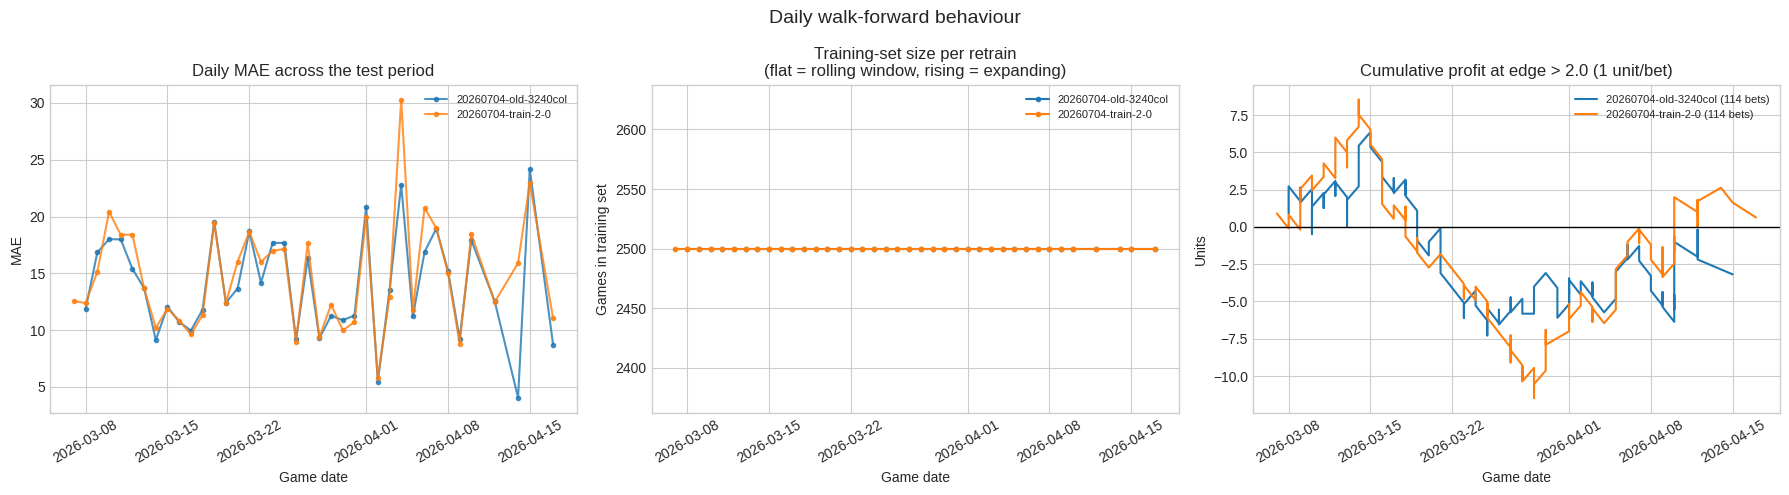

In [9]:
def load_walk_forward(run_name: str, comparison_key: str) -> dict | None:
    """Daily retrain log + pooled predictions for one run, if it ran daily."""
    run_dir = EXPERIMENT_ROOT / run_name
    daily_path = run_dir / "backtest_daily.csv"
    predictions_path = run_dir / "backtest_predictions.parquet"
    if not daily_path.exists() or not predictions_path.exists():
        return None

    daily = pd.read_csv(daily_path, parse_dates=["date", "train_start_date", "train_end_date"])
    predictions = pd.read_parquet(predictions_path)
    predictions["date"] = pd.to_datetime(predictions["date"])
    return {
        "key": comparison_key,
        "daily": daily.sort_values("date").reset_index(drop=True),
        "predictions": predictions.sort_values("date").reset_index(drop=True),
        "summary": (
            read_json(run_dir / "backtest_summary.json")
            if (run_dir / "backtest_summary.json").exists() else {}
        ),
    }


def cumulative_profit(predictions: pd.DataFrame, min_edge: float) -> pd.DataFrame:
    """Running P&L in units, staking 1 unit per qualifying bet."""
    bets = predictions.loc[predictions["predicted_edge"].abs() > min_edge].copy()
    if bets.empty:
        return bets.assign(profit=[], cumulative_profit=[])
    margin = bets["TOTAL_POINTS"] - bets["target_line"]
    bet_over = bets["predicted_edge"] > 0
    won = np.where(bet_over, margin > 0, margin < 0) & (margin != 0)
    push = margin == 0
    bets["profit"] = np.where(won, DECIMAL_ODDS - 1.0, np.where(push, 0.0, -1.0))
    bets["cumulative_profit"] = bets["profit"].cumsum()
    return bets


walks = [
    w for row in selected_runs.itertuples(index=False)
    if (w := load_walk_forward(row.run_name, str(row.comparison_key))) is not None
]

if not walks:
    display(Markdown(
        "_No daily walk-forward artifacts found. These runs used "
        "`holdout_evaluation: single_shot`; rerun with `daily_walk_forward` "
        "to populate this section._"
    ))
else:
    # --- leakage audit, before any chart is worth reading -------------------
    audit_rows = []
    for walk in walks:
        daily = walk["daily"]
        violations = int((daily["train_end_date"] >= daily["date"]).sum())
        audit_rows.append({
            "comparison_key": walk["key"],
            "game_days": len(daily),
            "games": int(daily["test_n_games"].sum()),
            "train_first_day": int(daily["train_n_games"].iloc[0]),
            "train_last_day": int(daily["train_n_games"].iloc[-1]),
            "future_leakage_days": violations,
        })
    audit = pd.DataFrame(audit_rows)
    display(audit)

    if audit["future_leakage_days"].sum() == 0:
        display(Markdown(
            "✅ **No day trained on data at or after its own prediction date.**"
        ))
    else:
        display(Markdown(
            "🚨 **Future data leaked into training on some days — these results are invalid.**"
        ))

    primary_edge = float(selected_runs["bet_min_edge"].dropna().iloc[0]) if (
        selected_runs["bet_min_edge"].notna().any()
    ) else 2.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for walk in walks:
        daily, key = walk["daily"], walk["key"]
        axes[0].plot(daily["date"], daily["mae"], marker=".", alpha=0.8, label=key)
        axes[1].plot(daily["date"], daily["train_n_games"], marker=".", label=key)
        bets = cumulative_profit(walk["predictions"], primary_edge)
        if not bets.empty:
            axes[2].plot(bets["date"], bets["cumulative_profit"], label=f"{key} ({len(bets)} bets)")

    axes[0].set_title("Daily MAE across the test period")
    axes[0].set_ylabel("MAE")
    axes[1].set_title("Training-set size per retrain\n(flat = rolling window, rising = expanding)")
    axes[1].set_ylabel("Games in training set")
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title(f"Cumulative profit at edge > {primary_edge} (1 unit/bet)")
    axes[2].set_ylabel("Units")
    for ax in axes:
        ax.set_xlabel("Game date")
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=8)
    fig.suptitle("Daily walk-forward behaviour", fontsize=14)
    plt.tight_layout()
    plt.show()

## 9. Configuration and feature-schema differences

Only fields that differ between the selected resolved configurations, split into those that change results and those that are just labels. Feature counts and overlap follow.

In [10]:
# Purely descriptive fields. They differ by design between runs and would
# otherwise bury the differences that actually change results.
LABEL_KEYS = {
    "experiment_name", "training_version", "comparison_group", "hypothesis",
    "tags", "data.data_version", "data.expected_checksum",
    "window_dir_label", "window_name_label",
    "experiment_root_dir", "model_output_root", "save_experiment_artifacts",
}

configs = {}
for row in selected_runs.itertuples(index=False):
    config = read_json(EXPERIMENT_ROOT / row.run_name / "config.json")
    configs[str(row.comparison_key)] = {
        key: display_value(value) for key, value in flatten_mapping(config).items()
    }

config_matrix = pd.DataFrame(configs).sort_index()
differs = config_matrix.apply(lambda r: r.astype(str).nunique(dropna=False) > 1, axis=1)
config_differences = config_matrix.loc[differs]

substantive = config_differences.loc[~config_differences.index.isin(LABEL_KEYS)]
labels_only = config_differences.loc[config_differences.index.isin(LABEL_KEYS)]

display(Markdown("**Differences that affect results**"))
if substantive.empty:
    display(Markdown("_None — these runs are configured identically._"))
else:
    display(substantive)
    # More than one substantive difference means the comparison cannot
    # attribute an outcome to any single change.
    changed = [k for k in substantive.index if not k.startswith("data.csv_path")]
    if len(substantive) > 1:
        display(Markdown(
            f"⚠️ **{len(substantive)} substantive fields differ** "
            f"({', '.join(substantive.index[:6])}"
            f"{', …' if len(substantive) > 6 else ''}). "
            "With more than one moving part, a difference in results cannot be "
            "attributed to any one of them."
        ))

if not labels_only.empty:
    display(Markdown("**Descriptive differences (no effect on results)**"))
    display(labels_only)

**Differences that affect results**

,20260704-old-3240col,20260704-train-2-0
data.csv_path,data/train_data/old_training_data_until_20260704.csv,data/train_data/training_data_2_0_20260704.csv
optuna.timeout,12600,4500


⚠️ **2 substantive fields differ** (data.csv_path, optuna.timeout). With more than one moving part, a difference in results cannot be attributed to any one of them.

**Descriptive differences (no effect on results)**

,20260704-old-3240col,20260704-train-2-0
data.data_version,20260704-old-3240col,20260704-train-2-0
data.expected_checksum,sha256:f73aa98c82119b42,None
experiment_name,total_points_2500_old_games_20260704,total_points_2500_games_train_2_0
hypothesis,Compare different versions of the training-data code by training the same TOTAL_POINTS experiment on the different f...,Compare different versions of the training-data code by training the same TOTAL_POINTS experiment on the different f...
tags,"[""total_points"", ""wide_search_space"", ""dataset_ab"", ""overnight"", ""old_3240col""]","[""total_points"", ""wide_search_space"", ""dataset_ab"", ""overnight"", ""train_2_0""]"
training_version,old,2.0


In [11]:
feature_sets = {}
feature_rows = []
for row in selected_runs.itertuples(index=False):
    payload = read_json(EXPERIMENT_ROOT / row.run_name / "feature_schema.json")
    features = set(payload["feature_names"])
    feature_sets[str(row.comparison_key)] = features
    feature_rows.append({"comparison_key": row.comparison_key, "n_features": len(features)})
display(pd.DataFrame(feature_rows))

if len(feature_sets) == 2:
    (name_a, features_a), (name_b, features_b) = feature_sets.items()
    overlap = pd.DataFrame([{
        "run_a": name_a, "run_b": name_b,
        "common_features": len(features_a & features_b),
        "only_a": len(features_a - features_b),
        "only_b": len(features_b - features_a),
        "jaccard_similarity": len(features_a & features_b) / len(features_a | features_b),
    }])
    display(overlap.style.format({"jaccard_similarity": "{:.2%}"}))

,comparison_key,n_features
0,20260704-old-3240col,2055
1,20260704-train-2-0,1458


,run_a,run_b,common_features,only_a,only_b,jaccard_similarity
0,20260704-old-3240col,20260704-train-2-0,1306,749,152,59.18%


## 10. Betting behaviour by edge threshold

ROI must always be read beside the number of bets surviving at the same threshold. Tail thresholds look spectacular precisely because almost nothing survives them.

Note the multiple-comparisons trap: with 7 thresholds × N runs, at 95% confidence you should *expect* roughly one "significant" cell by chance. A single significant threshold surrounded by insignificant neighbours is noise, not a discovery.

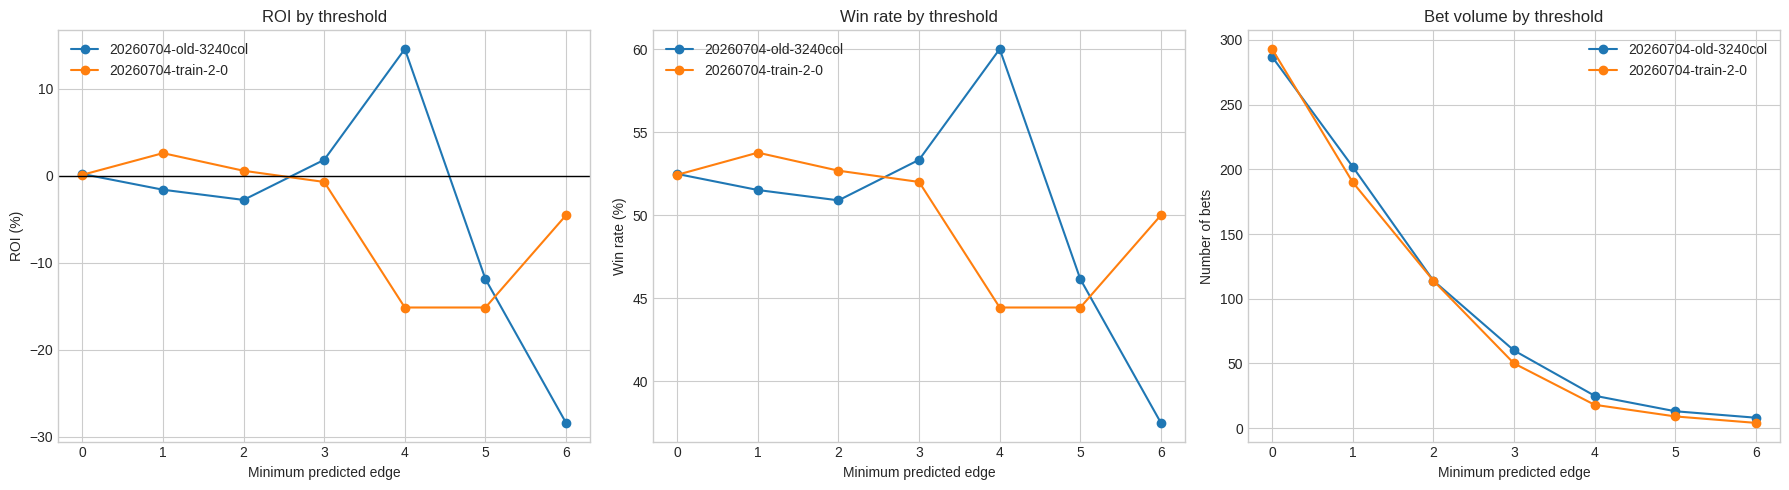

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for row in selected_runs.itertuples(index=False):
    sweep_path = EXPERIMENT_ROOT / row.run_name / "betting_sweep.csv"
    if not sweep_path.exists():
        continue
    sweep = pd.read_csv(sweep_path)
    label = str(row.comparison_key)
    axes[0].plot(sweep["min_edge"], sweep["roi"] * 100, marker="o", label=label)
    axes[1].plot(sweep["min_edge"], sweep["win_rate"] * 100, marker="o", label=label)
    axes[2].plot(sweep["min_edge"], sweep["n_bets"], marker="o", label=label)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("ROI by threshold")
axes[0].set_ylabel("ROI (%)")
axes[1].set_title("Win rate by threshold")
axes[1].set_ylabel("Win rate (%)")
axes[2].set_title("Bet volume by threshold")
axes[2].set_ylabel("Number of bets")
for ax in axes:
    ax.set_xlabel("Minimum predicted edge")
    ax.legend()
plt.tight_layout()
plt.show()

## 11. Optuna search behaviour

Whether the search improved with more trials, and whether one run completed materially fewer trials because of its timeout — an unfair tuning comparison is a common reason two configurations look different when they are not.

Trials are selected lexicographically (best MAE within tolerance, then best OU accuracy), so the lowest-MAE trial is not necessarily the one used.

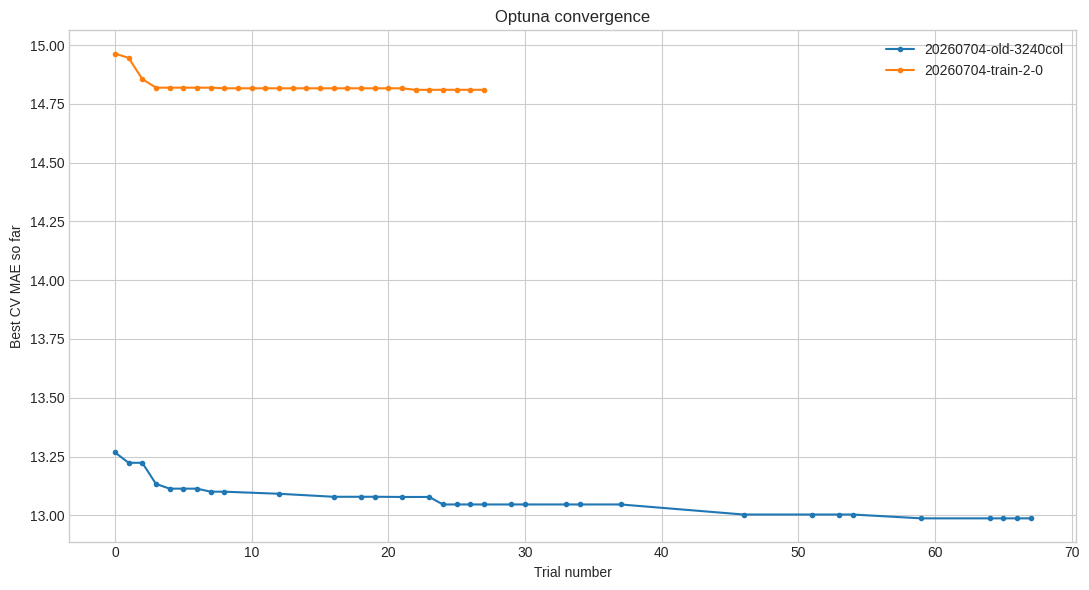

,comparison_key,completed_trials,best_cv_mae
0,20260704-old-3240col,33,12.9870
1,20260704-train-2-0,28,14.8101


In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
trial_summaries = []
for row in selected_runs.itertuples(index=False):
    trials_path = EXPERIMENT_ROOT / row.run_name / "optuna_trials.csv"
    if not trials_path.exists():
        continue
    trials = pd.read_csv(trials_path).sort_values("trial")
    trials["best_mae_so_far"] = trials["value_mae"].cummin()
    label = str(row.comparison_key)
    ax.plot(trials["trial"], trials["best_mae_so_far"], marker=".", label=label)
    trial_summaries.append({
        "comparison_key": label,
        "completed_trials": len(trials),
        "best_cv_mae": trials["value_mae"].min(),
    })
ax.set_xlabel("Trial number")
ax.set_ylabel("Best CV MAE so far")
ax.set_title("Optuna convergence")
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame(trial_summaries).style.format({"best_cv_mae": "{:.4f}"}))

## 12. Prediction residuals

Residual timelines reveal a model that fails during a particular stretch of its holdout. Runs on different holdout periods are plotted descriptively — they are not paired predictions and should not be read as a head-to-head.

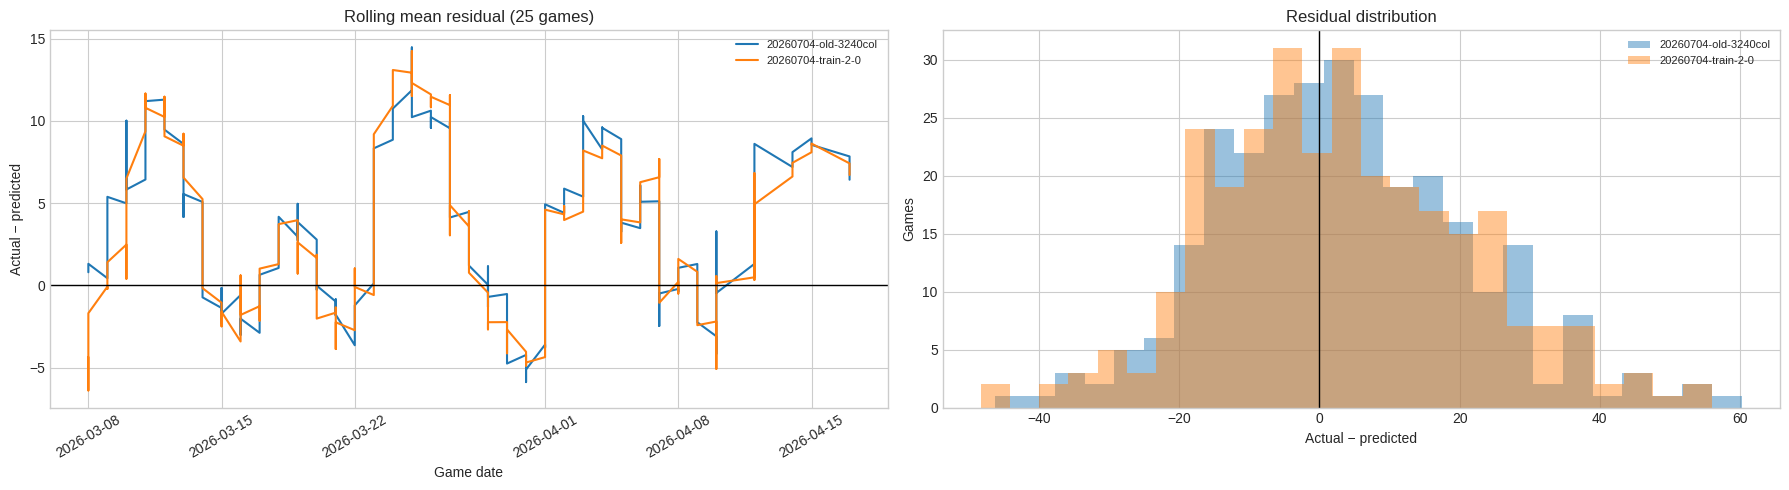

- **20260704-old-3240col**: mean residual +3.357, sd 17.954 over 287 games.

- **20260704-train-2-0**: mean residual +3.019, sd 18.358 over 293 games.

In [14]:
def resolve_date_column(df: pd.DataFrame) -> str | None:
    """Find the date column in a saved predictions frame.

    The two evaluation modes name it differently: the daily walk-forward emits
    `date` (one row per predicted game-day), while single_shot emits the
    configured `GAME_DATE`. Handle both so this section works either way.
    """
    for candidate in ("date", "GAME_DATE", "game_date"):
        if candidate in df.columns:
            return candidate
    return None


fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plotted = 0
for row in selected_runs.itertuples(index=False):
    predictions_path = EXPERIMENT_ROOT / row.run_name / "final_test_predictions.parquet"
    if not predictions_path.exists():
        continue
    predictions = pd.read_parquet(predictions_path).copy()

    date_column = resolve_date_column(predictions)
    if date_column is None:
        display(Markdown(
            f"_Skipping {row.comparison_key}: no date column in its predictions._"
        ))
        continue

    predictions[date_column] = pd.to_datetime(predictions[date_column])
    predictions = predictions.sort_values(date_column).reset_index(drop=True)
    predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
    predictions["rolling_residual"] = predictions["residual"].rolling(25, min_periods=8).mean()

    label = str(row.comparison_key)
    axes[0].plot(predictions[date_column], predictions["rolling_residual"], label=label)
    axes[1].hist(predictions["residual"].dropna(), bins=25, alpha=0.45, label=label)
    plotted += 1

axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Rolling mean residual (25 games)")
axes[0].set_ylabel("Actual − predicted")
axes[0].set_xlabel("Game date")
axes[0].tick_params(axis="x", rotation=30)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual − predicted")
axes[1].set_ylabel("Games")
if plotted:
    for ax in axes:
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# A rolling residual sitting persistently off zero means a systematic bias the
# model is not correcting -- different from noisy scatter around zero.
for row in selected_runs.itertuples(index=False):
    path = EXPERIMENT_ROOT / row.run_name / "final_test_predictions.parquet"
    if not path.exists():
        continue
    predictions = pd.read_parquet(path)
    residual = predictions["y_true"] - predictions["y_pred"]
    display(Markdown(
        f"- **{row.comparison_key}**: mean residual {residual.mean():+.3f}, "
        f"sd {residual.std(ddof=1):.3f} over {len(residual)} games."
    ))

## Interpretation checklist

In rough order of how often each one invalidates a conclusion:

1. **Is the gap bigger than the seed noise?** (§6) The first question, because it can dismiss everything below it. If two runs differ by less than one run's own spread across seeds, there is nothing to explain.
2. **Same evaluation cohort?** (§2) Different holdout dates means the baselines differ too, and MAE/ROI are not comparable.
3. **Only one thing changed?** (§9) More than one substantive config difference and no outcome can be attributed to any of them.
4. **Is there enough volume to conclude anything?** (§5) ~115 holdout bets cannot separate a real edge from a lucky one at −110. Prefer `cv_roi` (~5× the bets) for *ranking* configurations, and read its per-fold consistency, not just the pooled number.
5. **Is the CV edge consistent?** (§4, §5) Mean edge over fold-to-fold spread matters more than the headline `cv_mae`. An edge carried by two folds out of ten is not an edge.
6. **Does CV agree with the test set?** (§3) A large `cv_roi − roi` gap is selection overfitting: the folds chose the hyperparameters, so they flatter them.
7. **Does it beat the *line*, not just the other model?** Both `baseline_holdout_mae` and the harder `bias_baseline_roi`.
8. **Would the edge have survived at a bettable price?** (§7) Beating the close proves information; beating the open proves it was capturable. The line moves ~2.5 points, more than the bet trigger.
9. **Is the profit steady or one lucky week?** (§8) The cumulative curve, not the average.
10. **Is a "significant" threshold real?** (§10) With 7 thresholds you expect ~1 false positive at 95%.
11. **Was tuning fair?** (§11) Similar completed trial counts.

Record the conclusion in the experiment's `hypothesis` field or the campaign README — not in the plots, which get regenerated.